In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "JaredLasley"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
* The objective of this experiment is to determine if controller grip material affects the comfort level of the controller.

**Question 2.** Specify the outcome variable
* **Outcome** = Comfort(continuous numeric variable)

**Question 3.** Specify the independent variable. What are some possible lurking variables?
* **IV** = Material (nominal categorical variable).
* **Lurking** = There could be a lurking variable if the professional gamers selected are not representative of the general populace due to some unseen difference in controller prefrence. This could be mitigated by repeating with the experiment with gamers whos patterns of play more closely match the general controller-buying population.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.
* A completely randomized design would be appropriate here because we have five mutually exclusive treatments we'd like to compare and have no other knowable sources of variation from lurking variables.We are randomly assigning the controllerss without many other sources of variation that we would need to control for in a more complex design.
**Question 5.** State the null and alternative hypotheses for this experiment.
$$ \begin{align}
H_0&: \text{Mean comfort rating between controller grip materials are the same} \\
H_1&: \text{Mean comfort rating between controller grip materials are different}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

* To interpret these results, we can see that controllers with silicone grips possess a mean comfort rating about 1.4 points higher than the controllers made with rubber grips this difference represents approximately $2\sigma$, thus implying a difference of moderate size. Additionally, we can see that there is some overlap of the boxes of plastic, rubber, and metal suggesting there may not be a significant difference between the three groups. In context, these observations support the alternative hypothesis more strongly.




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
          mean       std
Material                
Metal     5.39  0.877433
Plastic   5.93  0.620125
Rubber    6.23  0.702456
Silicone  7.63  0.700872


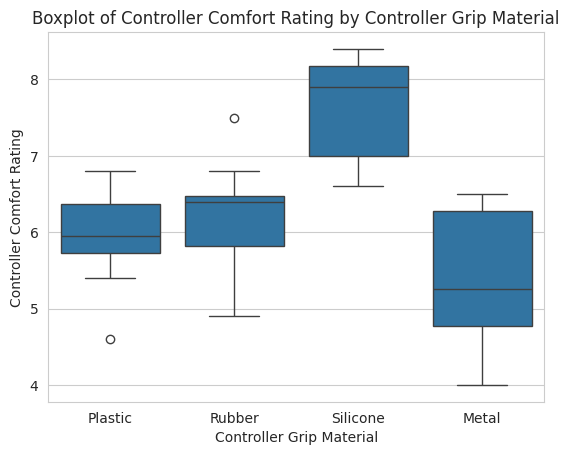

In [2]:
## Import Necessary Packages to Perform Exploratory Analysis ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Dog Toys.xlsx file ##

gamer = pd.read_excel("Video Game Controllers.xlsx")

## Check Data Integrity ##

gamer.info()

## Calculate Group Means and Standard Deviations ##

summary_stats = gamer.groupby('Material')['Comfort'].agg(['mean','std'])

print(summary_stats)

## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Material",y="Comfort",data=gamer)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of Controller Comfort Rating by Controller Grip Material", loc='center')
plt.xlabel("Controller Grip Material")
plt.ylabel("Controller Comfort Rating")
plt.show()

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

- To interpret the results of the normality testing, we can see from the QQ plot that the majority of data points fall on or near the 45 degree line bisecting the graph, approximately 10% of the data deviates from the bottom quarter of 45 degree. While there is some deviation it is limited in scope and is confined to the tail of the data.Thus, the visual intrepretation suggests normality. This is confirmed by the calculated Shapiro-Wilk P-value of 0.9710. Since $p > \alpha = 0.05$, this tells us the data more strongly supports $$H_0$$, therefore the assumption of normality is supported by the data.

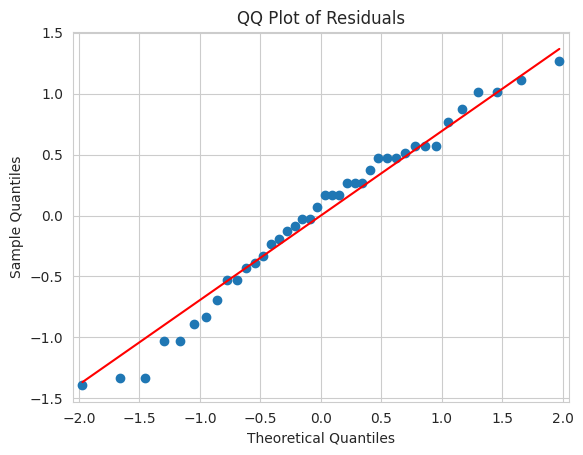

Shapiro-Wilk Test Statistic: 0.9710
Shapiro-Wilk Test P-Value: 0.3874
Fail to reject null hypothesis: Residuals are normally distributed.


In [3]:
## Import Libraries ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

## Fit One Way ANOVA Model ##

gamer_mod = ols("Comfort~Material",data=gamer).fit()

## Extract Model Residuals ##

residuals = gamer_mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

#Inferential Testing

## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

- As we can see, for each group mean (shown by the vertical lines), the residuals are generally centered around 0, which implies that the residual mean is approximately 0. Further, we don't see any points greater than +3 or less than -3, which indicates no obvious outliers. Additionally, each vertical line appears to be of similar height and I do not see any cone shapes forming in the data. Thus, from visualization I would concluded that the assumption of homoscedasticity is met. This finding is supported by the calculated B-P test p-value of 0.5674. Since $p > \alpha = 0.05$, this tells us the data more strongly supports $$H_0$$, therefore the assumption of homoscedasticity is supported by the data.

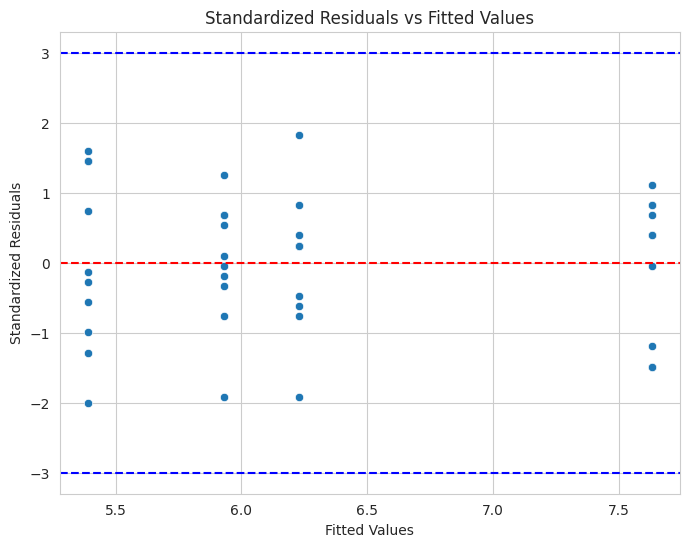

BP Test F-statistic: 0.684288131275624
BP Test F p-value: 0.5674916917969977
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [4]:
## Obtain Standardized Residuals ##

standardized_residuals = gamer_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = gamer_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

#Inferential Testing of Homoscedasticity

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(gamer_mod.resid,gamer_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

-The F-statistic and P-value of the one-way ANOVA model are as follows.

F-Statistic: 17.07

P-value: 4.62e-07

Given that p < 0.05 we reject the null hypothesis. the data more strongly supports the alternative hypothesis, indicating that there is a statistically significant difference in mean comfort rating between at least two of the controller grip materials.

In [5]:
print(gamer_mod.summary())

                            OLS Regression Results                            
Dep. Variable:                Comfort   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     17.07
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           4.62e-07
Time:                        00:24:45   Log-Likelihood:                -42.132
No. Observations:                  40   AIC:                             92.26
Df Residuals:                      36   BIC:                             99.02
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                5.3900 

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

- These results, as shown by the adjusted $p < 0.05$, indicate that the mean comfort rating for controllers wiah a silicone grip is greater than metal, plastic, and ruber gripped controllers. However, the differences in mean comfort rating between metal, plastic, and rubbber gripped controllers were not found to be statistically different.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


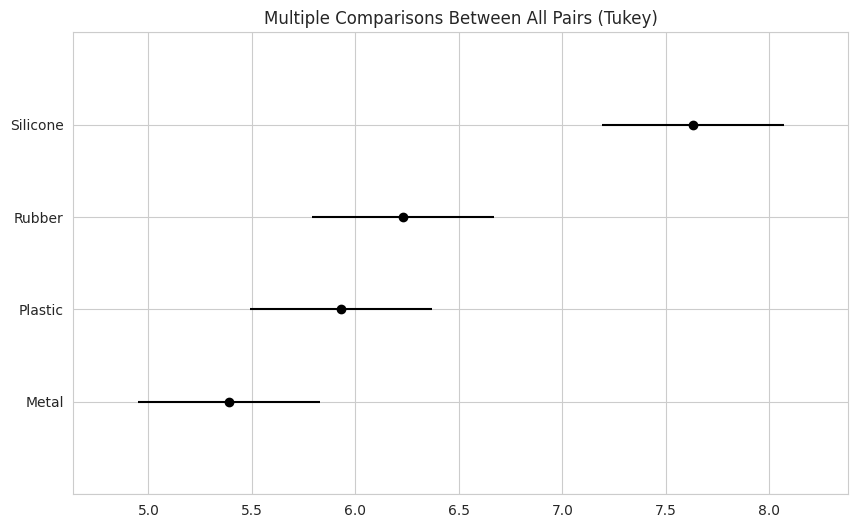

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

tukey_result = pairwise_tukeyhsd(endog=gamer['Comfort'], groups=gamer['Material'],
                                 alpha=0.05)

## Print Tukey Visualization ##

tukey_result.plot_simultaneous()

## Print Tukey Table ##

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

- In conclusion our analyses have determined that the material of a controller's grip does have an effect on the mean comfort rating of the controller. Specifically we determined that there is a statistically significant difference in comfort rating between controllers manufactured with a silicone grip versus a metal, rubber, or plastic grip. Potential limiations of the experiment would be unforseen variations in the expermental population which could have an impact on true relevance to market trends when compared to an average gamer. Future experiments of this nature could be improved by improving experimental controls and increasing the pool of candidates to a wider range of participants. Inclusion of these improvements would increase the robustness of our conclusions.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
* The objective of this experiment is to compare the outcomes of two different methods of instructing undergraduate nursing students.

**Question 2.** Specify the outcome variable
* The outcome variable is the percentage score attained on the 50 question quiz, which is a quantitative, continuous variable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?
* The independent variable is Method(nominal categorical variable) and the blocking factor is Experience(nominal categorical variable). Possible lurking variables include each the amount of time each student spends studying material outside of class or the time of the day each student attends the class. These could affect student performace depending on learning method.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.
* A randomized block design would be appropriate in this case because of the presence of a single known blocking factor. A completely randomized design would not be appropriate here due to the presence of the known blocking factor. If we were to use a CRD the known variace determined from the blocking factor Experience would instead be attributed to unknown variance which would weaken the model.

**Question 5.** State the null and alternative hypotheses for this experiment.
$$ H_0: \mu_1 = \mu_2 $$

$$ H_1:\mu_1 \neq \mu_2 $$
**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

* Both the summary statistics and data visualizations more strongly support the aternative hyothesis. In the boxplot you can see an overlap of approximately 25% between the boxplots, however there remains a visibly distinct region betwen the plots of the two teaching methods. This is supported by the summary statistics where we can see that the mean score of students instructed with the VR method is approximately $1.1\sigma$ greater than the mean quiz score of the traditional teaching method.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
             mean       std
Method                     
Traditional  30.8  6.716829
VR           38.5  6.969860


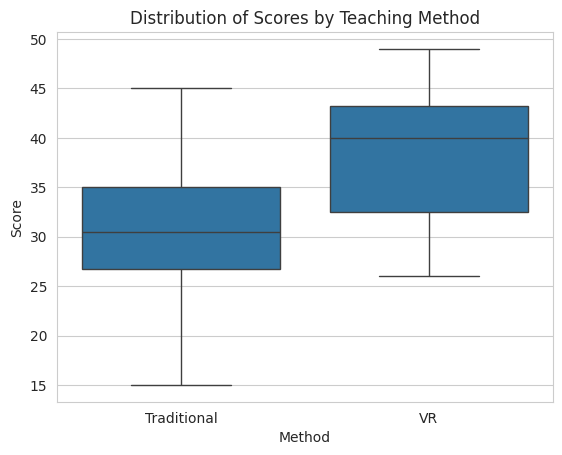

In [7]:
## Specify necessary libraries ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
2
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
## Load the dataset ##
nurse = pd.read_excel("Nursing VR Study.xlsx")
## Data Integrity Check ##
print(nurse.info())
## Produce Means and Standard Deviations of the Scores for Each Teaching Method ##
print(nurse.groupby('Method')['Score'].agg(['mean', 'std']))
## Visualize the Distribution of Scores for Each Teaching Method ##
## Using Seaborn's boxplot ##
sns.boxplot(x='Method', y='Score', data=nurse)
plt.title('Distribution of Scores by Teaching Method')
plt.show()

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

* Both the statistical testing and visual method more strongly support the assumption of normality. Almost all data points are located coincident to the 45 degree trend line of the qq plot except for one at the bottom tail of the 45 degree line, this supports the assumption of normality. Additionally, the Shapiro-Wilk test confirms this analysis. With a p-value of 0.9173 we fail to reject the null hypothesis. It follows then, that the assumption of normailty has been met.



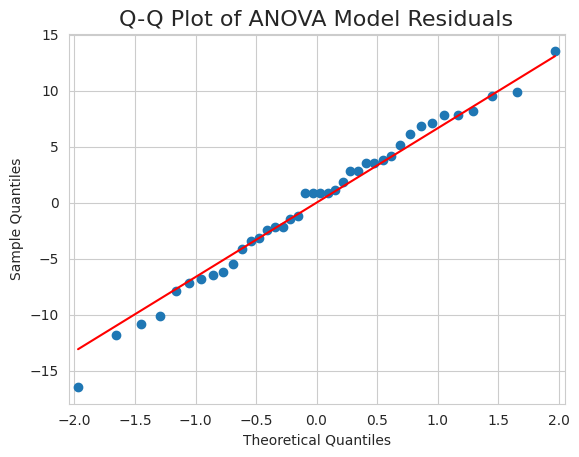

Shapiro-Wilk Test Statistic: 0.9869
Shapiro-Wilk Test P-Value: 0.9173
The residuals are normally distributed (fail to reject H0).


In [9]:
## Fit ANOVA Model ##


## fitting model ##

nurse_mod = ols("Score~Method+Experience",data=nurse).fit()

## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Exercise Treatment
## is evaluated after adjusting for BMI Category ##

nurse_tab = sm.stats.anova_lm(nurse_mod,typ=3)

## Add Significance Column ##

nurse_tab["Significance"] = np.where(nurse_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Assessing Normality ##

## Import scipy ##

import scipy.stats as stats

## Extract Model Residuals ##

nurse_residuals = nurse_mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(nurse_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(nurse_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

* Both the statistical test and visualization more strongly support the assumption of homoscedasticity. The standardized vs residual plot appears to be generally centered on a mean of zero, futher there are no outliers beyond 3 standard deviation. The banding pattern seen the the residual plot can be explained by the presence of categorical variables. Additionally, no coning can be seen in the residual plot. For the B-P test we obtained a p-value of approximately 0.8208 which indicates that we fail to reject the null hypothesis. Therefore, the assumption of homoscedasticity has been met.

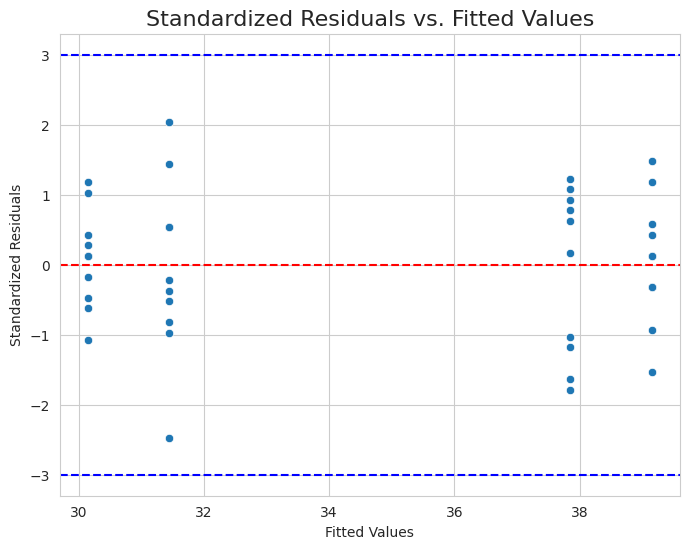

F-statistic: 0.19858503981404418
F p-value: 0.8207581702983743
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [10]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = nurse_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = nurse_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(nurse_mod.resid,nurse_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

* With an F-statistic of 12.44 and a p-value = 0.001 we reject the null hypothesis that there is no difference between the mean quiz score of each teaching method. The alternative hypothesis is more strongly supported.

In [12]:
## Print Only Teaching Method & Prior Knowledge Rows ##

print(nurse_tab.loc[["Method","Experience"]])

            sum_sq   df          F    PR(>F)     Significance
Method       592.9  1.0  12.441048  0.001140      Significant
Experience    16.9  1.0   0.354619  0.555135  Not Significant


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

A significant difference was determined from the post-hoc test between VR and traditional teaching methods. Students instructed with the new VR method showed quiz scores 7.7 points higher on average than those instructed with traditional methods alone.

Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


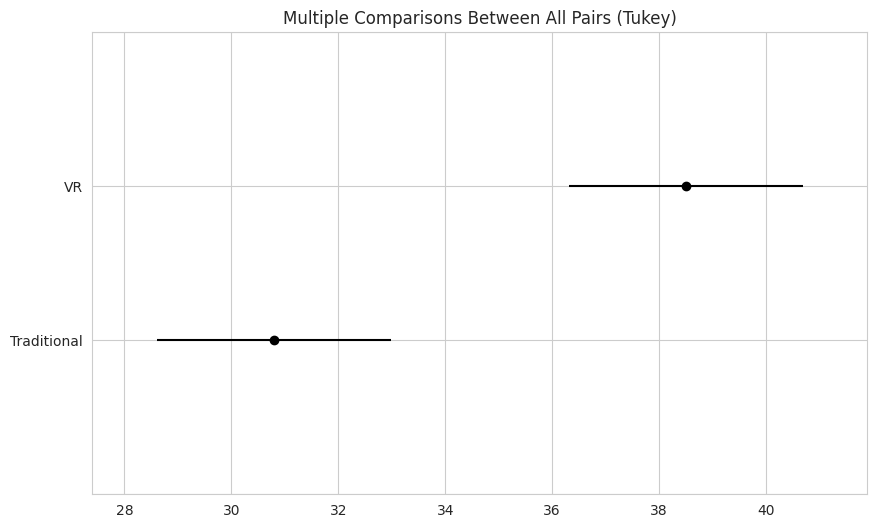

In [14]:
## Import pairwise_tukeyhsd function ##

from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test (Remember, we renamed Exercise Treatment to Exercise_Treatment) ##

tukey_result = pairwise_tukeyhsd(endog=nurse['Score'], groups=nurse['Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(tukey_result.plot_simultaneous())

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

* In conclusion our analyses have determined that there is a difference between the mean quiz scores of the two different teaching methods trialed. Specifically a significant difference of 7.7 points on average was found between the mean quiz scores of the VR and traditional teaching methods with the VR group scoring higher. Overall the best performing learning method from this experiment was VR learning. Potential limitations of this experiment include a limited sample size as well as additional lurking factors related to the students which have an interaction with quiz score. Future iterations of this experiment could impove upon this study by collecting data across a broader population and by accounting for additional variables which impact student success beyond teaching method and prior experience with the subject.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.
* Generally when it comes to studies with human participants there can be many lurking factors. People live highly varied lives with a vast swath of different experiences which can affect their perspective or performance in a study. As such, it is highly naive to assume that by controlling for one factor you will explain a signifigant proportion of the variance in any human behavior.

**Question 2.** What is the purpose of post-hoc tests?
* The purpose of post-hoc test are to determine which groups differ specifically after conducting an ANOVA. The ANOVA lets us know if a difference between groups exist. The post-hoc tests let us know which group(s) have the difference(s).

**Question 3.** Explain the difference between RBD and LSD.
* Randomized Block Design is appropriate for experiments with a single known blocking factor. While in contrast Latin Square Design is only appropriate in situations where there are two known blocking factors with the same number of treatments.

**Question 4.** Explain why randomization is important in designing experiments.
* Randomization is important in designing experiments for several reasons. By randomizing experimental candidtates we elimate possible selection bias. Additionally if there are lurking variables present by randomizing the experiment you would spread the lurking variable randomly across groups mitigating its effect. Finally, randomization is important becasue the majority of inferential testing we conduct are based on the assumption that the data provided is a random sample.

**Question 5.** Explain why replication is important in designing experiments.
* Replication is important in experimental design for several reasons. By repeating an experiment we are able to determine variance within a group. Additionally, it increases the robustness and statistical power of our experiment as the total number of particpants increases. Finally, experiments should be replicable to determine the validity of their conclusions by ensuring the results were not sweked by erroneous data or an outlier.